# Predicting Passenger Survival on the Titanic Using Machine Learning

**1. Importing packages & loading data**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**2. Understanding the data**

In [25]:
# --- 2. Understanding the data ---

print("📋 Dataset Information:")
print("-" * 50)
print(f"Total passengers: {len(train_df)}")
print(f"Features: {len(train_df.columns)}")
print(f"Missing values: {train_df.isnull().sum().sum()}")
print(f"Survived: {train_df['Survived'].sum()} ({train_df['Survived'].mean()*100:.1f}%)")
print(f"Died: {len(train_df) - train_df['Survived'].sum()} ({(1-train_df['Survived'].mean())*100:.1f}%)")
print("-" * 50)


📋 Dataset Information:
--------------------------------------------------
Total passengers: 891
Features: 12
Missing values: 866
Survived: 342 (38.4%)
Died: 549 (61.6%)
--------------------------------------------------


In [23]:
print("\n📋 Column Descriptions:")
descriptions = {
    'PassengerId': 'Unique ID for each passenger',
    'Survived': 'Survival (0 = No, 1 = Yes)',
    'Pclass': 'Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)',
    'Name': 'Passenger name',
    'Sex': 'Gender',
    'Age': 'Age in years',
    'SibSp': '# of siblings/spouses aboard',
    'Parch': '# of parents/children aboard',
    'Ticket': 'Ticket number',
    'Fare': 'Passenger fare',
    'Cabin': 'Cabin number',
    'Embarked': 'Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)'
}

for col, desc in descriptions.items():
    if col in train_df.columns:
        print(f"  • {col}: {desc}")


📋 Column Descriptions:
  • PassengerId: Unique ID for each passenger
  • Survived: Survival (0 = No, 1 = Yes)
  • Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
  • Name: Passenger name
  • Sex: Gender
  • Age: Age in years
  • SibSp: # of siblings/spouses aboard
  • Parch: # of parents/children aboard
  • Ticket: Ticket number
  • Fare: Passenger fare
  • Cabin: Cabin number
  • Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


**3a. Data Cleaning - Analysis**

Missing Values in Training Data:
          Missing Count  Percentage
Cabin               687   77.104377
Age                 177   19.865320
Embarked              2    0.224467



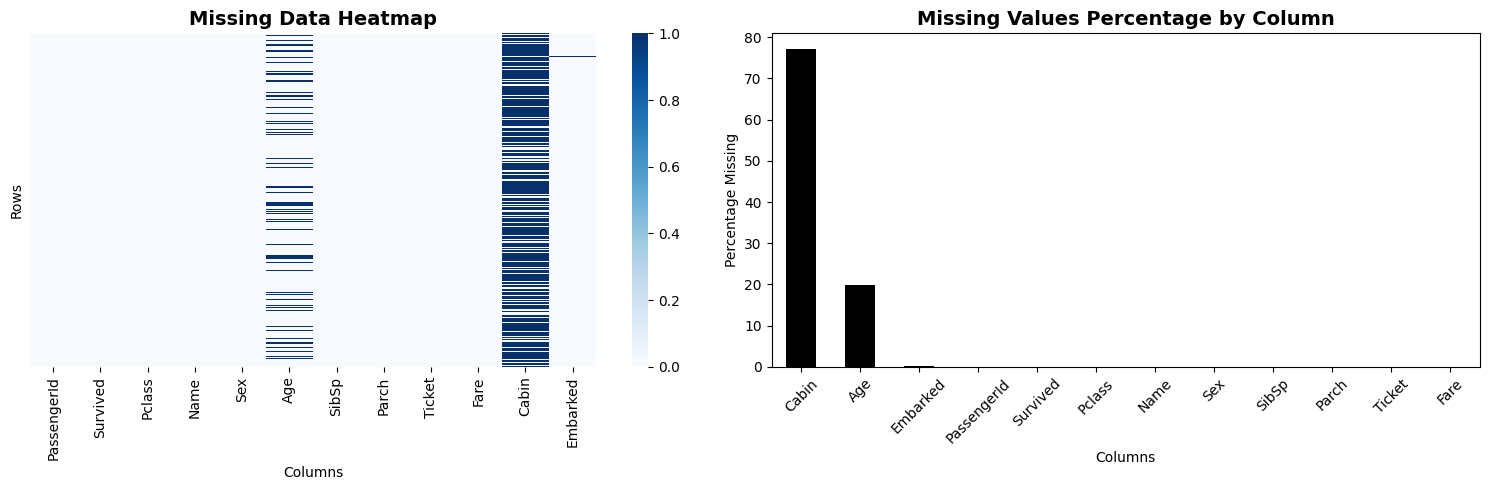


 Observations:
• Cabin has the most missing values (77%) - we'll drop this column
• Age has 20% missing - we'll impute these
• Embarked has only 2 missing - we'll fill with mode


In [37]:
missing_data = train_df.isnull().sum().sort_values(ascending=False)
missing_percent = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Missing Values in Training Data:")
print(missing_df)
print("\n" + "="*50)

# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
sns.heatmap(train_df.isnull(), yticklabels=False, cbar=True, cmap='Blues', ax=axes[0])
axes[0].set_title('Missing Data Heatmap', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Rows')

# Bar plot
missing_percent.plot(kind='bar', ax=axes[1], color='black')
axes[1].set_title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Columns')
axes[1].set_ylabel('Percentage Missing')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Observations:")
print("• Cabin has the most missing values (77%) - we'll drop this column")
print("• Age has 20% missing - we'll impute these")
print("• Embarked has only 2 missing - we'll fill with mode")

**3b. Data Cleaning - Handling Missing Values**

In [39]:
# Create a working copy
df = train_df.copy()
test_clean = test_df.copy()

# Function to clean data
def clean_data(data):
    """Clean the dataset by handling missing values"""
    data = data.copy()

    # Fill Age with median (by class and gender for better accuracy)
    data['Age'] = data.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )

    # Fill Embarked with mode
    data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

    # Fill Fare with median (for test set)
    if 'Fare' in data.columns:
        data['Fare'].fillna(data['Fare'].median(), inplace=True)

    # Drop Cabin (too many missing)
    if 'Cabin' in data.columns:
        data.drop('Cabin', axis=1, inplace=True)

    return data

# Clean both datasets
df = clean_data(df)
test_clean = clean_data(test_clean)

print("✅ Data cleaning complete!")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print("\nData types after cleaning:")
print(df.dtypes)

✅ Data cleaning complete!
Remaining missing values: 2

Data types after cleaning:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object


/var/folders/r4/_xlk3w9977j_mmlz7v7577pw0000gn/T/ipykernel_12436/2339790206.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
/var/folders/r4/_xlk3w9977j_mmlz7v7577pw0000gn/T/ipykernel_12436/2339790206.py:20: ChainedAssignmentError: A value is being set on a copy of

**4. Exploratory Data Analysis (EDA)**


<>:78: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:78: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/r4/_xlk3w9977j_mmlz7v7577pw0000gn/T/ipykernel_12436/3398777884.py:78: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
/var/folders/r4/_xlk3w9977j_mmlz7v7577pw0000gn/T/ipykernel_12436/3398777884.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette=['#FF6B6B', '#4ECDC4'])


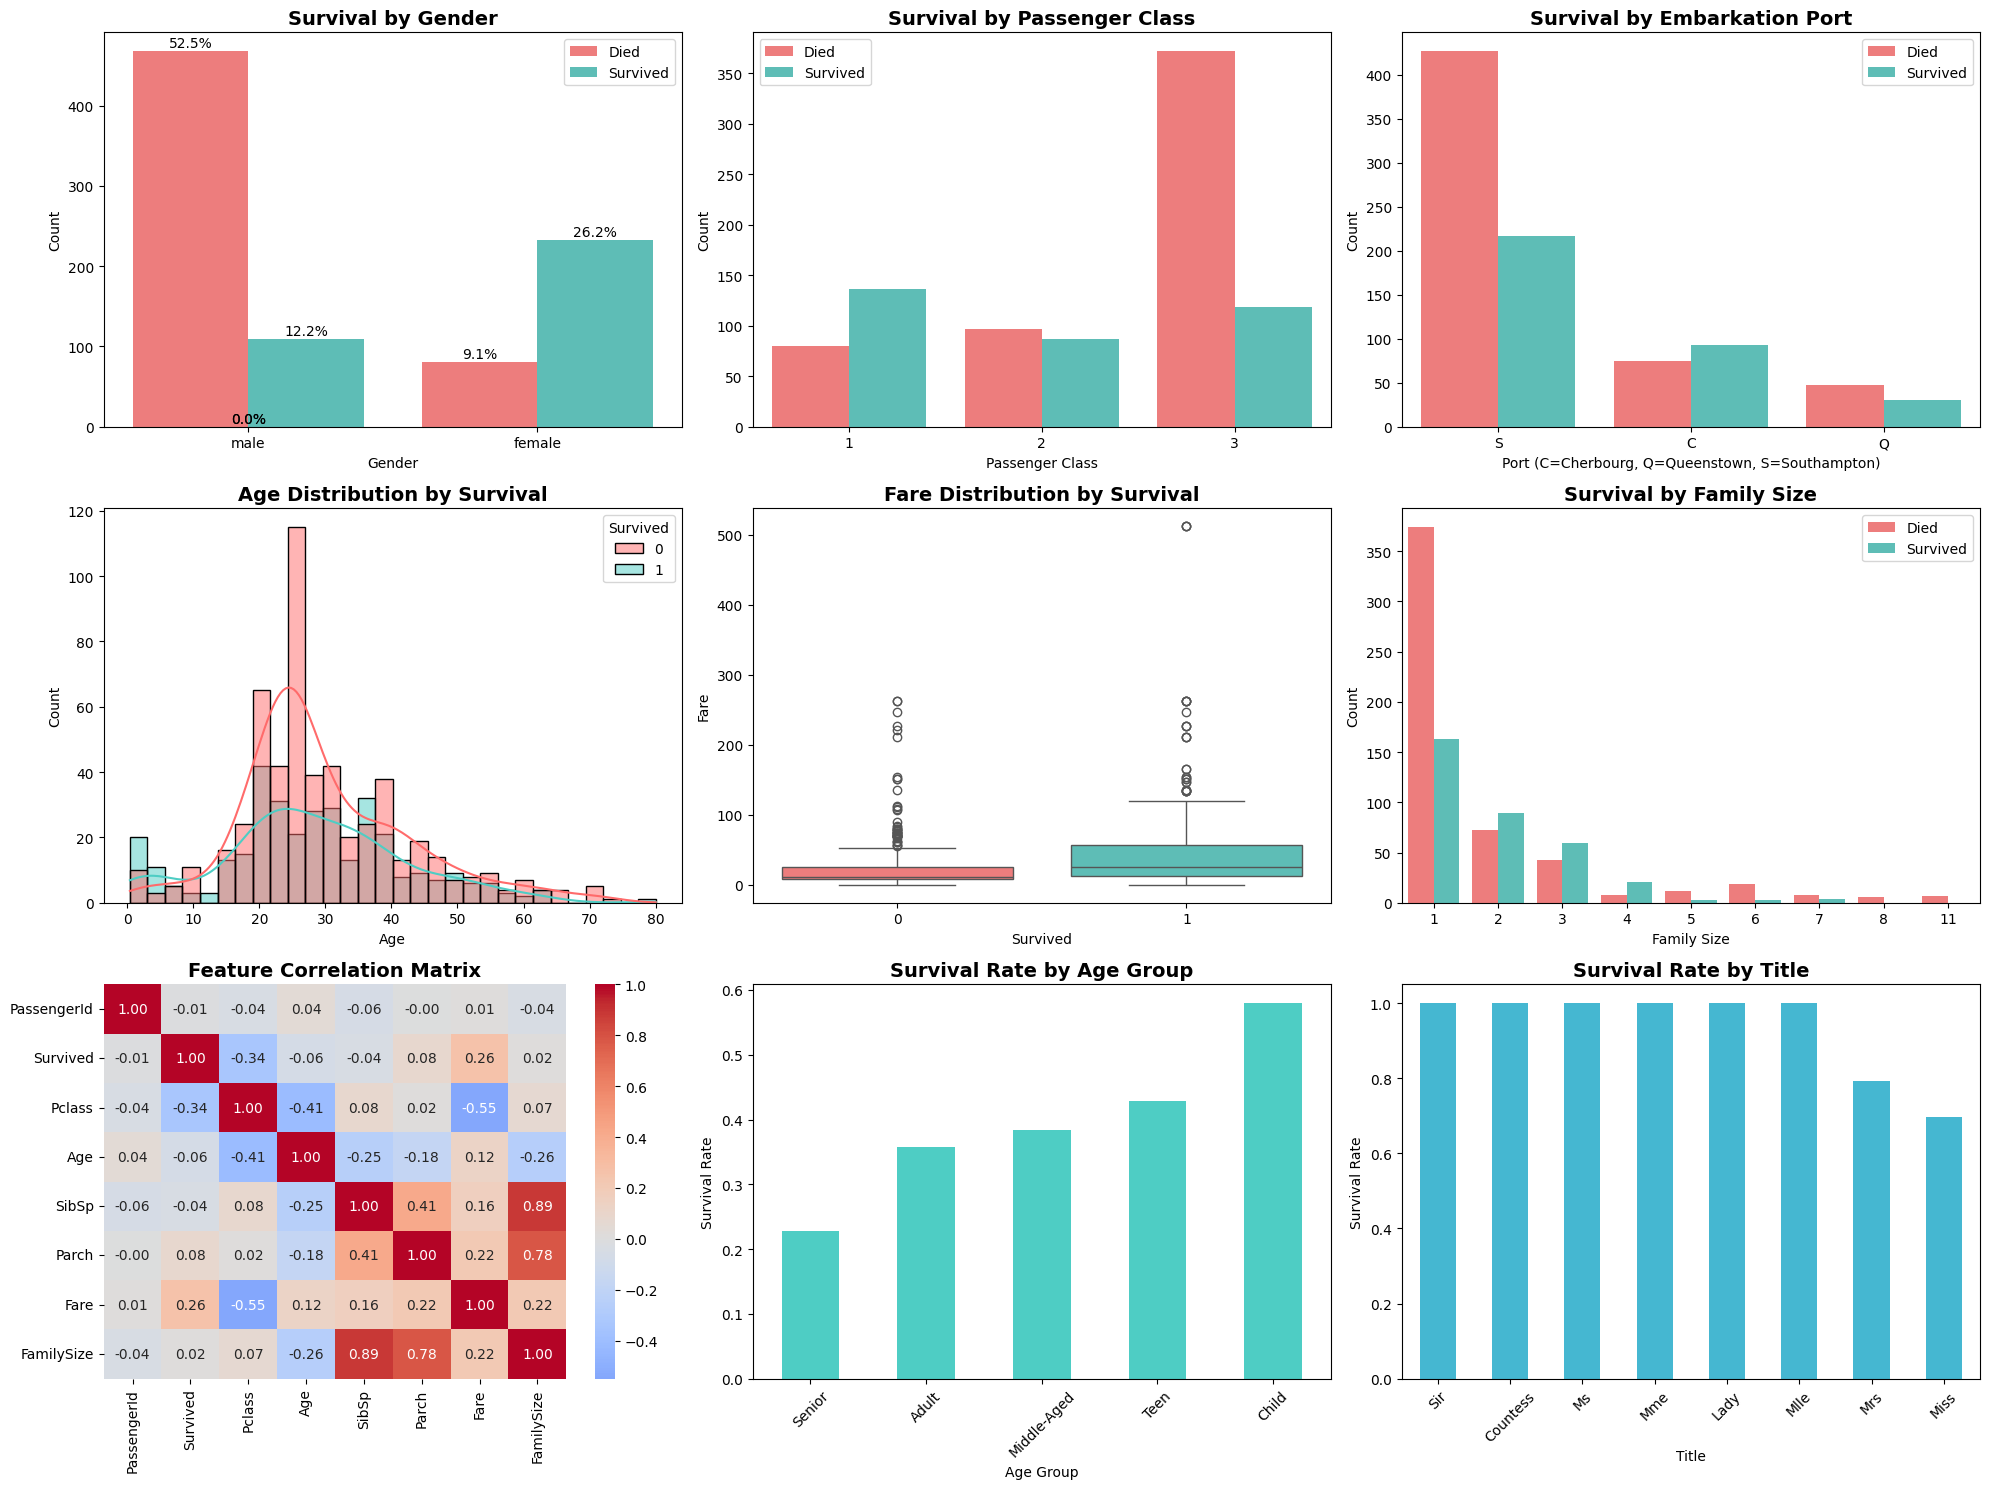


 Key Insights from EDA:
• Women survival rate: 74.2%
• Men survival rate: 18.9%
• 1st class survival rate: 63.0%
• 3rd class survival rate: 24.2%
• Children (under 12) survival rate: 57.4%


In [42]:
# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 15))

# 1. Survival by Gender
ax1 = plt.subplot(3, 3, 1)
sns.countplot(x='Sex', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# Add percentages
total = len(df)
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2., height + 5,
             f'{height/total*100:.1f}%', ha="center")

# 2. Survival by Passenger Class
ax2 = plt.subplot(3, 3, 2)
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# 3. Survival by Embarkation Port
ax3 = plt.subplot(3, 3, 3)
sns.countplot(x='Embarked', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Embarkation Port', fontsize=14, fontweight='bold')
plt.xlabel('Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# 4. Age Distribution
ax4 = plt.subplot(3, 3, 4)
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Age Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')

# 5. Fare Distribution
ax5 = plt.subplot(3, 3, 5)
sns.boxplot(x='Survived', y='Fare', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
plt.xlabel('Survived')
plt.ylabel('Fare')

# 6. Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
ax6 = plt.subplot(3, 3, 6)
sns.countplot(x='FamilySize', hue='Survived', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Survival by Family Size', fontsize=14, fontweight='bold')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])

# 7. Correlation Heatmap
ax7 = plt.subplot(3, 3, 7)
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=ax7, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# 8. Survival Rate by Age Group
ax8 = plt.subplot(3, 3, 8)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])
survival_by_age = df.groupby('AgeGroup')['Survived'].mean().sort_values()
survival_by_age.plot(kind='bar', ax=ax8, color='#4ECDC4')
plt.title('Survival Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)

# 9. Survival Rate by Title (we'll create this later, placeholder for now)
ax9 = plt.subplot(3, 3, 9)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
title_survival = df.groupby('Title')['Survived'].mean().sort_values(ascending=False).head(8)
title_survival.plot(kind='bar', ax=ax9, color='#45B7D1')
plt.title('Survival Rate by Title', fontsize=14, fontweight='bold')
plt.xlabel('Title')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('images/comprehensive_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key insights
print("\n Key Insights from EDA:")
print("="*50)
print(f"• Women survival rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"• Men survival rate: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"• 1st class survival rate: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"• 3rd class survival rate: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"• Children (under 12) survival rate: {df[df['Age']<12]['Survived'].mean()*100:.1f}%")